In [1]:
# imports
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import geopandas as gpd

In [2]:
current = Path.cwd()
current

PosixPath('/Users/kevinxu23/Desktop/team-nuclear-family/notebooks')

In [4]:
data_center_data = Path(current / "../data/processed/data_centers.csv")
county_data = Path(current / "../data/processed/county_boundaries.geojson")

print(data_center_data)
print(data_center_data.exists())

print(county_data)
print(county_data.exists())

/Users/kevinxu23/Desktop/team-nuclear-family/notebooks/../data/processed/data_centers.csv
False
/Users/kevinxu23/Desktop/team-nuclear-family/notebooks/../data/processed/county_boundaries.geojson
False


In [6]:
from pathlib import Path

current = Path.cwd()
print("Current working directory:", current)
print("Project root:", current.parent)

Current working directory: /Users/kevinxu23/Desktop/team-nuclear-family/notebooks
Project root: /Users/kevinxu23/Desktop/team-nuclear-family


In [7]:
project_root = Path.cwd().parent

matches = list(project_root.glob("**/data_centers.csv"))
matches

[PosixPath('/Users/kevinxu23/Desktop/team-nuclear-family/processed_data/data_centers.csv')]

In [8]:
data_center_data = matches[0]
print(data_center_data)
print(data_center_data.exists())

/Users/kevinxu23/Desktop/team-nuclear-family/processed_data/data_centers.csv
True


In [9]:
data_centers = pd.read_csv(data_center_data)
data_centers.head()

,id,type,lat,lon,name,operator,city,state_abbr
0,751881301,node,38.902888,-77.029149,CoreSite DC1,CoreSite,NaN,NaN
1,1825907839,node,35.103293,-106.589349,Southwest Cyberport,NaN,Albuquerque,NM
2,2590601520,node,42.437882,-123.328630,FCR,NaN,Grants Pass,OR
3,2607827436,node,32.775025,-117.070888,SDSU Computer Room,NaN,NaN,NaN
4,3406467087,node,25.791545,-80.317748,NocRoom Miami IT Services,NaN,NaN,NaN


In [11]:
print("Shape:", data_centers.shape)
print("\nColumns:")
print(data_centers.columns.tolist())

print("\nInfo:")
data_centers.info()

Shape: (1412, 8)

Columns:
['id', 'type', 'lat', 'lon', 'name', 'operator', 'city', 'state_abbr']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1412 non-null   int64  
 1   type        1412 non-null   object 
 2   lat         1412 non-null   float64
 3   lon         1412 non-null   float64
 4   name        1165 non-null   object 
 5   operator    941 non-null    object 
 6   city        592 non-null    object 
 7   state_abbr  568 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 88.4+ KB


In [12]:
missing = data_centers.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(data_centers) * 100).round(2)
missing.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
state_abbr,844,59.77
city,820,58.07
operator,471,33.36
name,247,17.49
id,0,0.00
type,0,0.00
lat,0,0.00
lon,0,0.00


In [13]:
print("Exact duplicate rows:", data_centers.duplicated().sum())
print("Duplicate IDs:", data_centers["id"].duplicated().sum())
print("Duplicate coordinates:", data_centers.duplicated(subset=["lat", "lon"]).sum())

Exact duplicate rows: 0
Duplicate IDs: 0
Duplicate coordinates: 0


In [14]:
data_centers[["lat", "lon"]].describe()

,lat,lon
count,1412.000000,1412.000000
mean,38.893328,-94.793608
std,4.424125,17.161530
min,18.417436,-123.328630
25%,36.310911,-111.972420
50%,39.015989,-90.095625
75%,41.177380,-77.541042
max,48.757260,-66.051687


In [15]:
bad_points = data_centers[
    ~data_centers["lat"].between(18, 50) |
    ~data_centers["lon"].between(-130, -60)
]

print("Suspicious coordinate rows:", len(bad_points))
bad_points.head(20)

Suspicious coordinate rows: 0


,id,type,lat,lon,name,operator,city,state_abbr


In [16]:
print("Top types:")
print(data_centers["type"].value_counts(dropna=False))

print("\nTop states:")
print(data_centers["state_abbr"].value_counts(dropna=False).head(20))

print("\nTop operators:")
print(data_centers["operator"].value_counts(dropna=False).head(20))

Top types:
type
way     1306
node     106
Name: count, dtype: int64

Top states:
state_abbr
NaN    844
VA     115
CA      71
TX      45
AZ      41
IL      36
WA      20
NJ      20
GA      18
NY      16
OR      16
CO      16
NM      13
NV      10
NC      10
IA       9
FL       9
MD       7
OH       7
TN       7
Name: count, dtype: int64

Top operators:
operator
NaN                            471
Amazon Web Services            212
Google                          71
Digital Realty                  71
Microsoft                       55
Meta                            52
Flexential                      43
Equinix                         42
Quality Technology Services     39
CyrusOne                        24
NTT                             19
CoreSite                        19
Lumen Technologies              18
Centersquare                    16
Switch                          11
Stack Infrastructure             8
EdgeConneX                       8
Csquare                          7
Sabey  

In [17]:
data_centers["city"].value_counts(dropna=False).head(20)

city
NaN                  820
Ashburn               46
Sterling              34
Santa Clara           30
Manassas              15
Hillsboro             13
Dallas                13
San Jose              12
Leesburg              11
Elk Grove Village     11
Chandler              11
Chicago               11
Phoenix               10
Richardson             9
Mesa                   9
Tukwila                7
New Albany             7
San Antonio            7
Secaucus               6
Los Lunas              6
Name: count, dtype: int64

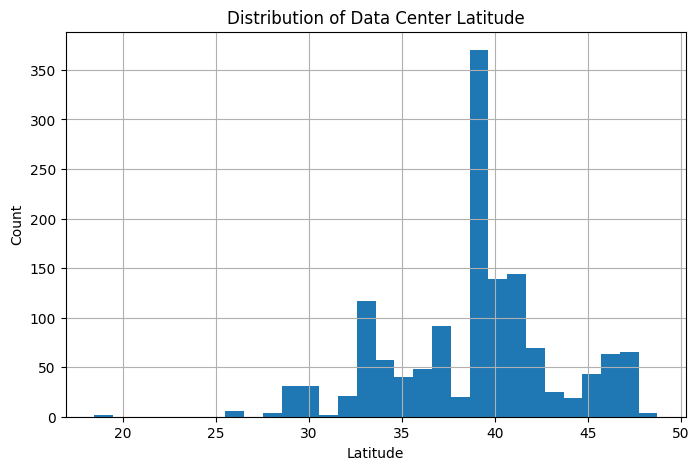

In [18]:
plt.figure(figsize=(8,5))
data_centers["lat"].hist(bins=30)
plt.title("Distribution of Data Center Latitude")
plt.xlabel("Latitude")
plt.ylabel("Count")
plt.show()

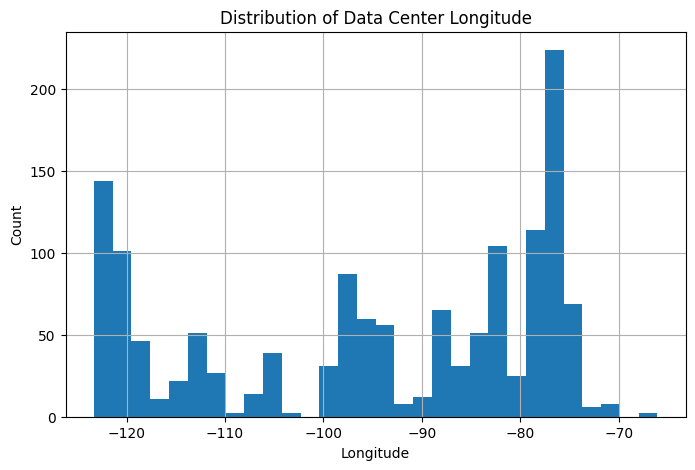

In [19]:
plt.figure(figsize=(8,5))
data_centers["lon"].hist(bins=30)
plt.title("Distribution of Data Center Longitude")
plt.xlabel("Longitude")
plt.ylabel("Count")
plt.show()

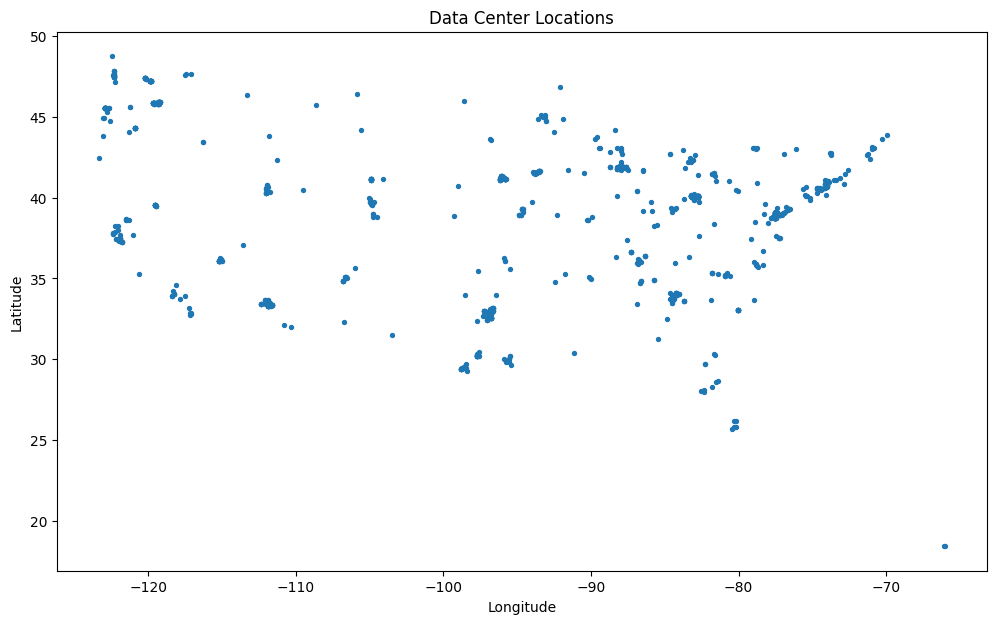

In [20]:
plt.figure(figsize=(12,7))
plt.scatter(data_centers["lon"], data_centers["lat"], s=8)
plt.title("Data Center Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

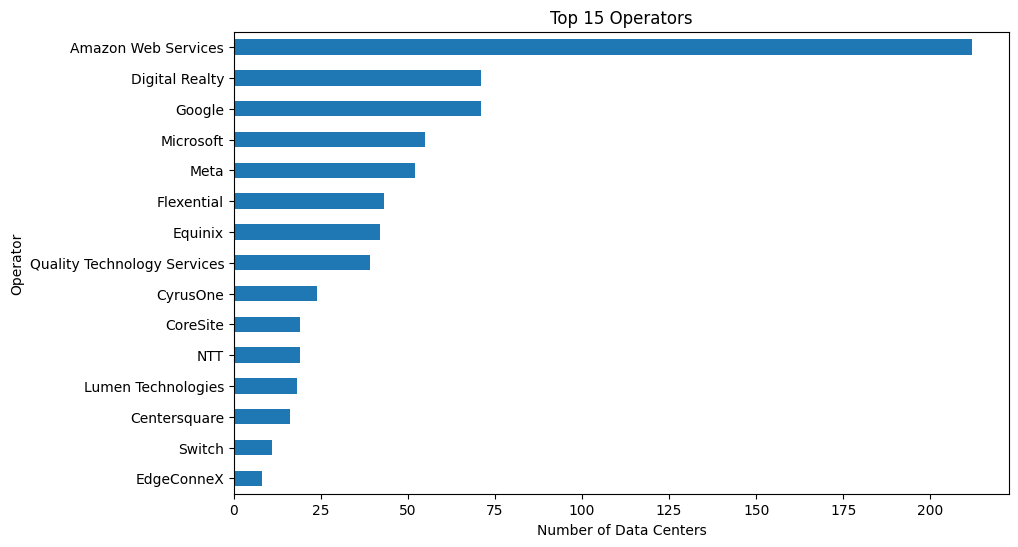

In [21]:
top_ops = data_centers["operator"].value_counts().head(15)

plt.figure(figsize=(10,6))
top_ops.sort_values().plot(kind="barh")
plt.title("Top 15 Operators")
plt.xlabel("Number of Data Centers")
plt.ylabel("Operator")
plt.show()

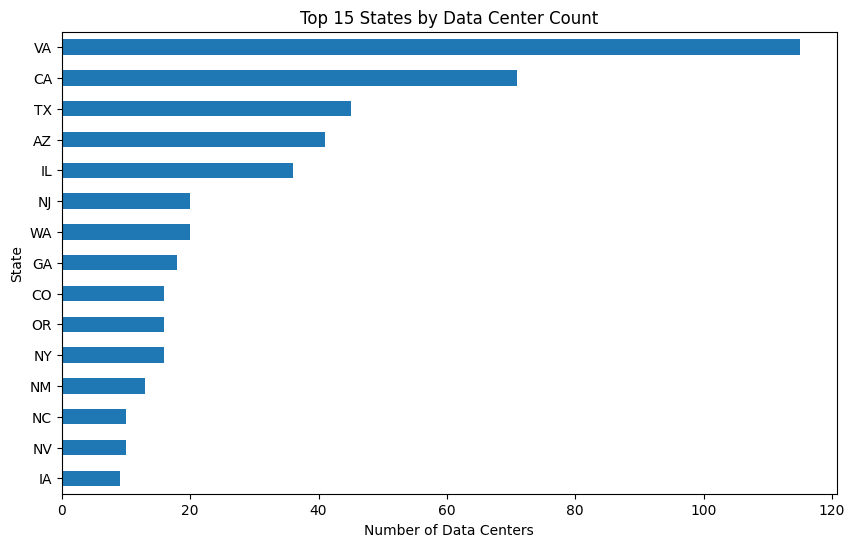

In [22]:
top_states = data_centers["state_abbr"].value_counts().head(15)

plt.figure(figsize=(10,6))
top_states.sort_values().plot(kind="barh")
plt.title("Top 15 States by Data Center Count")
plt.xlabel("Number of Data Centers")
plt.ylabel("State")
plt.show()

In [43]:
project_root = Path.cwd().parent

matches = (
    list(project_root.glob("**/county_boundaries.geojson")) +
    list(project_root.glob("**/*county*.geojson")) +
    list(project_root.glob("**/*county*.shp"))
)

print("Matches found:")
for m in matches:
    print(m)

Matches found:
/Users/kevinxu23/Desktop/team-nuclear-family/processed_data/county_boundaries.geojson
/Users/kevinxu23/Desktop/team-nuclear-family/processed_data/county_boundaries.geojson


In [28]:
project_root = Path.cwd().parent
county_data = project_root / "processed_data" / "county_boundaries.geojson"

print(county_data)
print(county_data.exists())

counties = gpd.read_file(county_data)
counties.head()

/Users/kevinxu23/Desktop/team-nuclear-family/processed_data/county_boundaries.geojson
True


,geoid,state_fips,county_fips,state_abbr,county_name,county_name_full,area_land_sqm,area_water_sqm,lat,lon,geometry
0,31039,31,039,NM,Cuming,Cuming County,1477563029,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55551 42.08996, -96.55517 41.742..."
1,53069,53,069,None,Wahkiakum,Wahkiakum County,680980771,61564427,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72656 46.38..."
2,35011,35,011,OH,De Baca,De Baca County,6016818946,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89202 34.6..."
3,31109,31,109,NM,Lancaster,Lancaster County,2169269688,22850324,+40.7835474,-096.6886584,"POLYGON ((-96.46363 40.52301, -96.91264 40.523..."
4,31129,31,129,NM,Nuckolls,Nuckolls County,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.27402 40.00266, -98.27357 40.350..."


In [29]:
print(counties.columns.tolist())

if "GEOID" in counties.columns and "geoid" not in counties.columns:
    counties = counties.rename(columns={"GEOID": "geoid"})

if "NAME" in counties.columns and "county_name" not in counties.columns:
    counties = counties.rename(columns={"NAME": "county_name"})

['geoid', 'state_fips', 'county_fips', 'state_abbr', 'county_name', 'county_name_full', 'area_land_sqm', 'area_water_sqm', 'lat', 'lon', 'geometry']


In [30]:
gdf_dc = gpd.GeoDataFrame(
    data_centers.copy(),
    geometry=gpd.points_from_xy(data_centers["lon"], data_centers["lat"]),
    crs="EPSG:4326"
)

In [31]:
counties = counties.to_crs("EPSG:4326")
print(counties.crs)
print(gdf_dc.crs)

EPSG:4326
EPSG:4326


In [32]:
dc_with_county = gpd.sjoin(
    gdf_dc,
    counties[["geoid", "geometry"]],
    how="left",
    predicate="within"
)

dc_with_county.head()

,id,type,lat,lon,name,operator,city,state_abbr,geometry,index_right,geoid
0,751881301,node,38.902888,-77.029149,CoreSite DC1,CoreSite,NaN,NaN,POINT (-77.02915 38.90289),630.0,11001
1,1825907839,node,35.103293,-106.589349,Southwest Cyberport,NaN,Albuquerque,NM,POINT (-106.58935 35.10329),2734.0,35001
2,2590601520,node,42.437882,-123.328630,FCR,NaN,Grants Pass,OR,POINT (-123.32863 42.43788),1666.0,41033
3,2607827436,node,32.775025,-117.070888,SDSU Computer Room,NaN,NaN,NaN,POINT (-117.07089 32.77503),538.0,06073
4,3406467087,node,25.791545,-80.317748,NocRoom Miami IT Services,NaN,NaN,NaN,POINT (-80.31775 25.79155),369.0,12086


In [33]:
dc_county = (
    dc_with_county.groupby("geoid")
    .size()
    .reset_index(name="dc_count")
)

dc_county.head()

,geoid,dc_count
0,01069,1
1,01071,3
2,01073,1
3,01089,5
4,04003,1


In [34]:
counties_eda = counties.merge(dc_county, on="geoid", how="left")
counties_eda["dc_count"] = counties_eda["dc_count"].fillna(0)

counties_eda[["geoid", "dc_count"]].head()

,geoid,dc_count
0,31039,0.0
1,53069,0.0
2,35011,0.0
3,31109,0.0
4,31129,0.0


In [35]:
print("Matched data centers:", dc_with_county["geoid"].notna().sum())
print("Unmatched data centers:", dc_with_county["geoid"].isna().sum())
print("Counties with at least 1 data center:", (counties_eda["dc_count"] > 0).sum())
print("Max dc_count in one county:", counties_eda["dc_count"].max())

Matched data centers: 1414
Unmatched data centers: 4
Counties with at least 1 data center: 245
Max dc_count in one county: 207.0


In [37]:
counties_eda["dc_count"].describe()

count    3235.000000
mean        0.437094
std         4.613509
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       207.000000
Name: dc_count, dtype: float64

In [38]:
(counties_eda["dc_count"] > 0).sum(), (counties_eda["dc_count"] == 0).sum()

(245, 2990)

In [44]:
top_counties = counties_eda.sort_values("dc_count", ascending=False)[
    ["geoid", "dc_count"]
].head(20)

top_counties

,geoid,dc_count
2961,51107,207.0
1947,06085,74.0
849,04013,60.0
1346,51153,57.0
2995,39089,34.0
2891,41059,31.0
2761,39049,31.0
615,48029,30.0
643,17031,29.0
2639,53025,29.0


In [47]:
## Key Findings

# The data center dataset contains complete latitude and longitude fields, making it suitable for spatial analysis.
# City and state fields are incomplete, so coordinates are the most reliable geographic identifiers.
# After spatially joining data centers to county boundaries, data center counts can be aggregated at the county level.
# The county-level distribution of data centers is highly right-skewed: most counties have zero or very few data centers, while a small number of counties contain large clusters.
# This suggests that data center infrastructure is geographically concentrated rather than evenly distributed across the U.S.

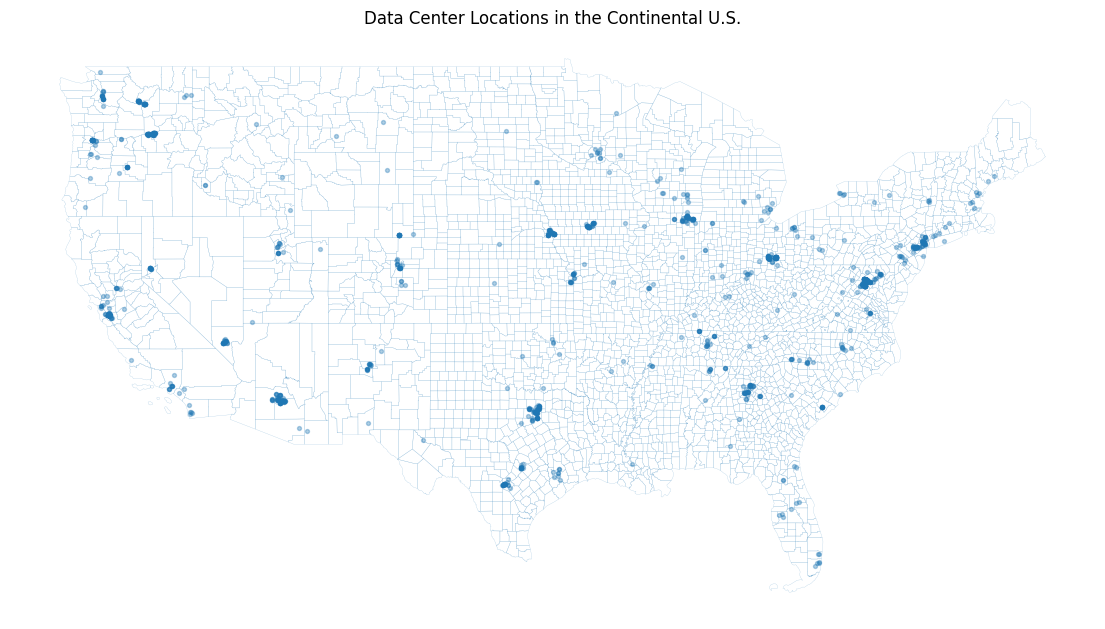

In [48]:
# Keep only CONUS-looking points
dc_conus = gdf_dc[
    gdf_dc["lon"].between(-125, -66) &
    gdf_dc["lat"].between(24, 50)
].copy()

counties_conus = counties[
    counties.bounds["minx"].between(-125, -66) &
    counties.bounds["miny"].between(24, 50)
].copy()

fig, ax = plt.subplots(figsize=(14, 8))
counties_conus.boundary.plot(ax=ax, linewidth=0.15, alpha=0.5)
dc_conus.plot(ax=ax, markersize=8, alpha=0.35)
ax.set_title("Data Center Locations in the Continental U.S.")
ax.axis("off")
plt.show()

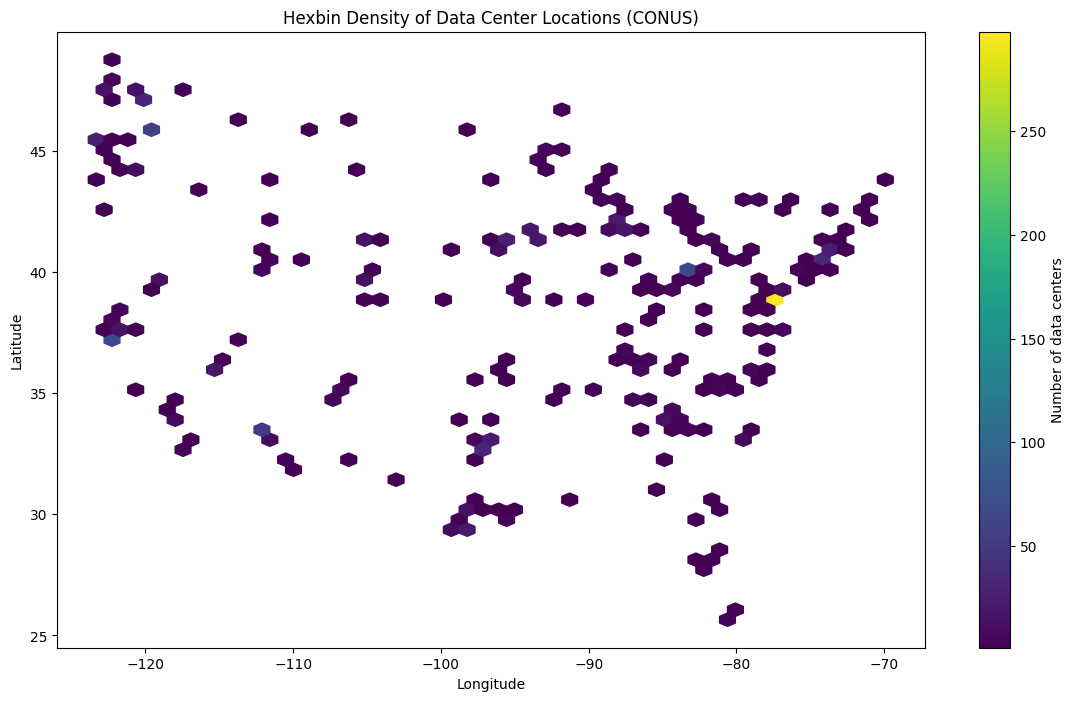

In [49]:
fig, ax = plt.subplots(figsize=(14, 8))
hb = ax.hexbin(
    dc_conus["lon"],
    dc_conus["lat"],
    gridsize=50,
    mincnt=1
)
ax.set_title("Hexbin Density of Data Center Locations (CONUS)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cb = plt.colorbar(hb, ax=ax)
cb.set_label("Number of data centers")
plt.show()

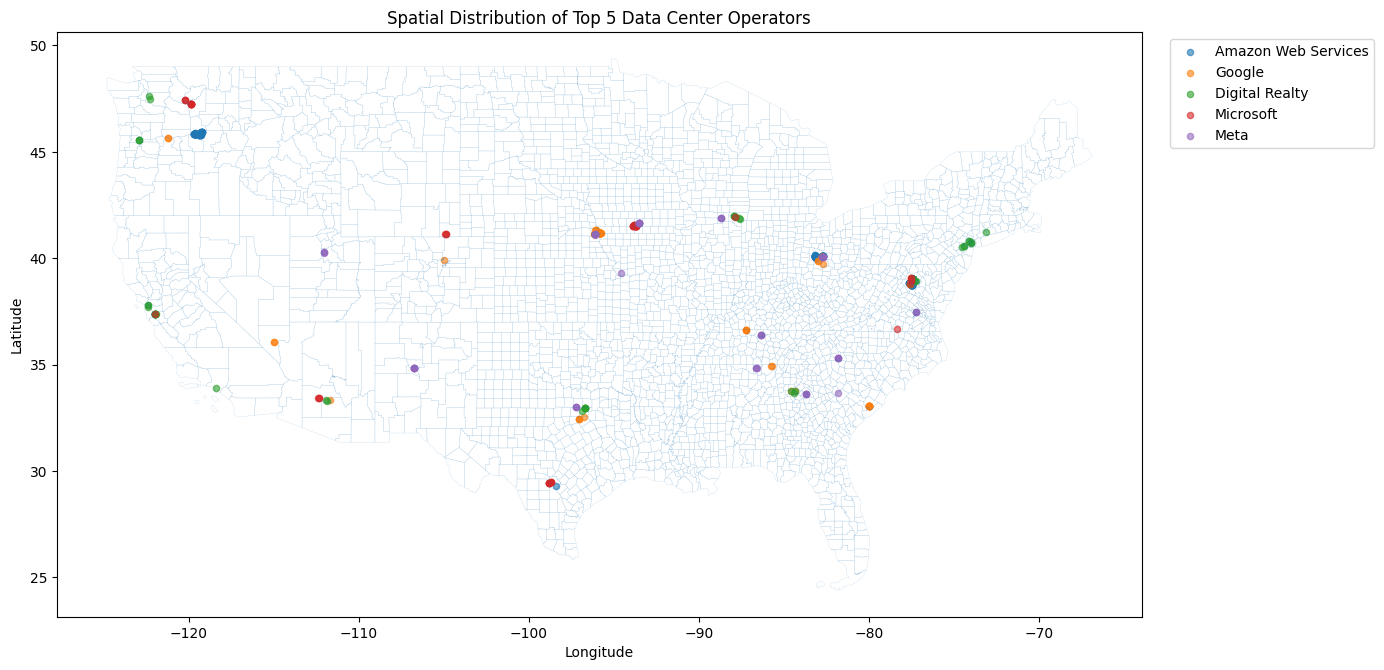

In [50]:
top_operators = data_centers["operator"].value_counts().head(5).index.tolist()
dc_top_ops = dc_conus[dc_conus["operator"].isin(top_operators)].copy()

fig, ax = plt.subplots(figsize=(14, 8))
counties_conus.boundary.plot(ax=ax, linewidth=0.15, alpha=0.4)

for op in top_operators:
    subset = dc_top_ops[dc_top_ops["operator"] == op]
    ax.scatter(subset["lon"], subset["lat"], s=20, alpha=0.6, label=op)

ax.set_title("Spatial Distribution of Top 5 Data Center Operators")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()